In [2]:
!kaggle datasets download -d crowdflower/twitter-airline-sentiment -p ~/CSE708

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment
License(s): CC-BY-NC-SA-4.0
  0%|                                               | 0.00/2.55M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 2.55M/2.55M [00:00<00:00, 929MB/s]


In [3]:
!unzip -o ~/CSE708/twitter-airline-sentiment.zip -d ~/CSE708/twitter_airline_sentiment

Archive:  /home/steps4growth/gmriechi/CSE708/twitter-airline-sentiment.zip
  inflating: /home/steps4growth/gmriechi/CSE708/twitter_airline_sentiment/Tweets.csv  
  inflating: /home/steps4growth/gmriechi/CSE708/twitter_airline_sentiment/database.sqlite  


In [5]:
!ls ~/CSE708

database.sqlite  twitter_airline_sentiment
Tweets.csv	 twitter-airline-sentiment.zip


## Load the dataset

In [2]:
import pandas as pd
df = pd.read_csv('~/CSE708/Tweets.csv')[['text', 'airline_sentiment']]
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## Data Preprocessing

In [3]:
import numpy as np
import re
from sklearn.preprocessing import LabelEncoder

Clean the text

In [4]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)   # remove special characters
    text = text.lower().strip()               # lowercase and strip
    return text


df['clean_text'] = df['text'].apply(clean_text)

# Encode sentiment labels
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['airline_sentiment'])

In [5]:
df[['airline_sentiment', 'label']].head(10)

,airline_sentiment,label
0,neutral,1
1,positive,2
2,neutral,1
3,negative,0
4,negative,0
5,negative,0
6,positive,2
7,neutral,1
8,positive,2
9,positive,2


# Train the models

## Deep Learning

**Goal**

To develop a **Long Short-Term Memory (LSTM)** based sentiment classification model caplable of capturing contextual dependencies and sequential patterns in textual data. This approach aims to automaticallt learn rich semantic representations from raw text to improve sentiment prediction accuracy

**Objective**

- Encode tweets into dense, meaningful word embeddings that preserve semantic relationships
- Utilize an LSTM network to model the temporal order and contextual flow of words within each tweet
- Evaluate the model's ability to generalize to unseen data and compare its performance with traditional (TF-IDF + Logistic Regression) and rule-based (VADER) approaches.

##### Split the data

In [6]:
from sklearn.model_selection import train_test_split

x_text = df['clean_text'].astype(str).values
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(x_text, y, test_size=0.2, stratify=y, random_state=42)

##### Tokenize and pad sequences

Build a vocabulary from the training text only to avoid data leakage, convert texts to integer sequences, and pad/truncate to a fixed length for the neural network

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [13]:
max_words = 10000   # vocabulary size
max_len = 100       # sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train = tokenizer.texts_to_sequences(X_train_text)
X_test = tokenizer.texts_to_sequences(X_test_text)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shapes: ", X_train.shape, X_test.shape)

Shapes:  (11712, 100) (2928, 100)


### Build the LSTM model

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_shape=(max_len,)),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])


model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

model.summary()

/home/steps4growth/gmriechi/.local/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,603 (5.07 MB)

 Trainable params: 1,329,603 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9494 - loss: 0.1433 - val_accuracy: 0.7806 - val_loss: 0.7741
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9632 - loss: 0.1098 - val_accuracy: 0.7708 - val_loss: 0.8429
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9673 - loss: 0.0949 - val_accuracy: 0.7742 - val_loss: 0.8996
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9727 - loss: 0.0804 - val_accuracy: 0.7486 - val_loss: 0.9905
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9758 - loss: 0.0710 - val_accuracy: 0.7670 - val_loss: 1.0544
Epoch 6/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9765 - loss: 0.0683 - val_accuracy: 0.7610 - val_loss: 1.1061
Epoch 7/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9790 - loss: 0.0608 - val_accuracy: 0.7670 - val_loss: 1.1887
Epoch 8/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9810 - loss: 0.0501 - val_accu

### Evaluate the model

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7473 - loss: 1.2579
Test Accuracy: 0.7473


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.84      1835
     neutral       0.52      0.58      0.55       620
    positive       0.68      0.62      0.65       473

    accuracy                           0.75      2928
   macro avg       0.68      0.68      0.68      2928
weighted avg       0.75      0.75      0.75      2928

[[1540  235   60]
 [ 188  357   75]
 [  91   91  291]]


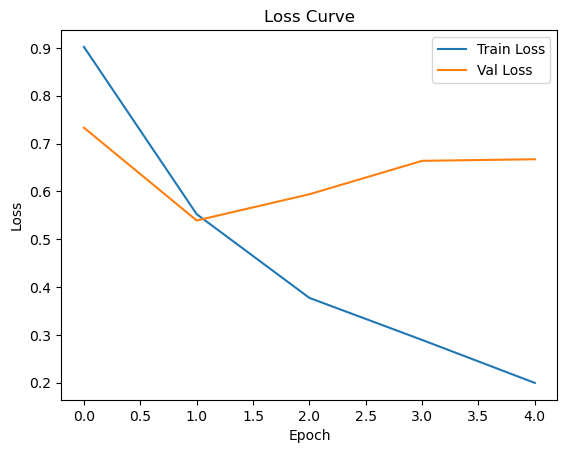

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


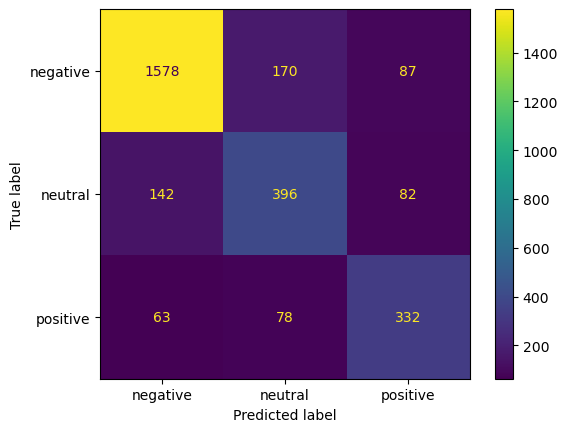

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=encoder.classes_).plot()

In [25]:
def predict_sent(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len)
    pred = np.argmax(model.predict(seq, verbose=0), axis=1)[0]
    return ['negative','neutral','positive'][pred]

print(predict_sent("Great service and smooth flight!"))
print(predict_sent("Delayed again... terrible experience."))

positive
negative


**Summary**

The Long Short-Term Memory (LSTM) network achieved an overall test accuracy of approximately 74.7% on the Twitter US Airline Sentiment dataset. The model effectively learned sequential patterns and contextual cues from the tweets, particularly excelling at identifying negative sentiments, which formed the largest portion of the dataset. However, it showed moderate confusion between neutral and positive classes, reflecting the inherent ambiguity of short social-media texts and the limited dataset size. The confusion matrix revealed strong performance on clearly polarized opinions but lower precision for neutral statements. Despite this, the LSTM demonstrated the capability to generalize sentiment from unseen tweets, correctly identifying intuitive examples such as “Great service and smooth flight!” (positive) and “Delayed again... terrible experience.” (negative).

**Conclusion**

The LSTM achieved strong generalization with 74.7% accuracy, performing best on negative tweets but struggling slightly with neutral sentiment. It illustrates the strength of deep learning for contextual understanding, though its full potential requires larger datasets.

# Machine Learning (TF-IDF + Logistic Regression)

<strong>Goal</strong>

Build a classic machine-learning model that uses TF-IDF features to represent text numerically and a logistic regression classifier to predict sentiment

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [27]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify=y, random_state=42)

In [29]:
clf = LogisticRegression(max_iter=200, solver='lbfgs')
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [30]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.7794


In [31]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))


Classification Report:
               precision    recall  f1-score   support

    negative       0.80      0.94      0.87      1835
     neutral       0.65      0.46      0.54       620
    positive       0.81      0.56      0.66       473

    accuracy                           0.78      2928
   macro avg       0.75      0.65      0.69      2928
weighted avg       0.77      0.78      0.76      2928



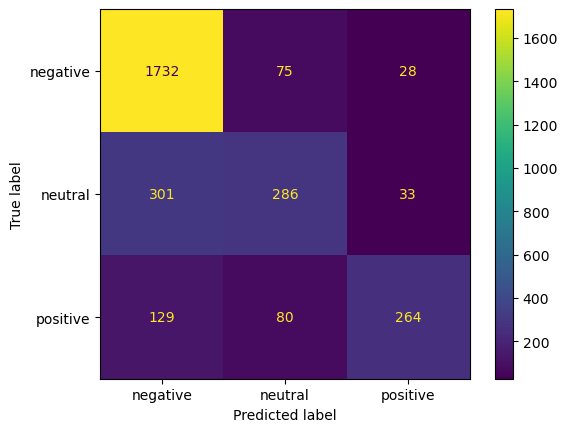

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['negative','neutral','positive'], cmap='viridis')

**Summary**

The **TF-IDF  Logistic Regression** Model achieved a test accuracy of 77.9%, better than the LSTM's 74.7%. This is because traditional ML t=techniques remain very competitibve on short, keyword-rich datasets such as tweets. The confusion matrix confirms that most miscladdifications occured between neutral and positive categories, a common challenge in sentiment analysis of short text

**Conclusion**

The Logistic Regression model achieved 77.9 % accuracy, performing especially well on negative tweets. It demonstrates that traditional ML methods with TF-IDF features can outperform deep models on small, text-driven datasets.